# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3359s 20us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

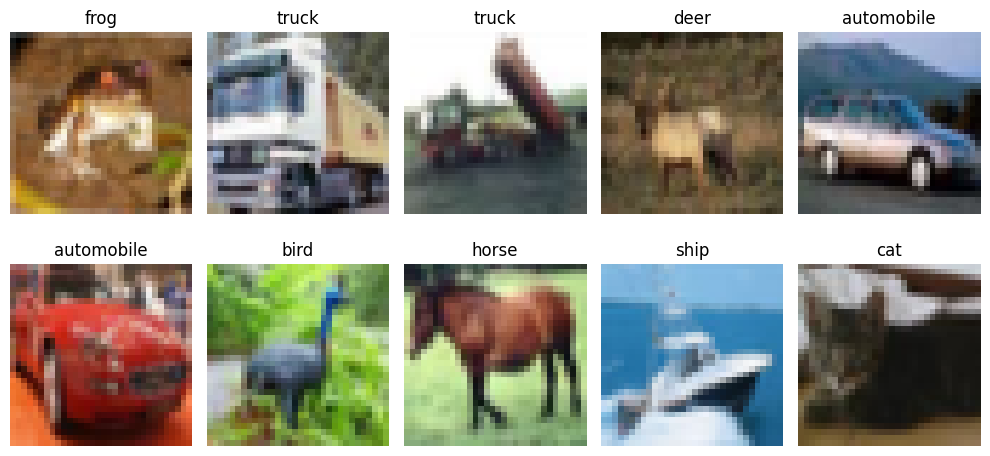

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.2585 - loss: 2.0155 - val_accuracy: 0.3412 - val_loss: 1.8630
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3138 - loss: 1.8843 - val_accuracy: 0.3508 - val_loss: 1.8193
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3308 - loss: 1.8406 - val_accuracy: 0.3620 - val_loss: 1.7856
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3432 - loss: 1.8020 - val_accuracy: 0.3798 - val_loss: 1.7500
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - accuracy: 0.3536 - loss: 1.7732 - val_accuracy: 0.3898 - val_loss: 1.7429
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3648 - loss: 1.7477 - val_accuracy: 0.3870 - val_loss: 1.7175
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3725 - loss: 1.7314 - val_accuracy: 0.3956 - val_loss: 1.7202
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3739 - loss: 1.7215 - 

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4222 - loss: 1.6522
ANN Test Accuracy: 0.4221999943256378


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 129ms/step - accuracy: 0.4672 - loss: 1.4912 - val_accuracy: 0.5382 - val_loss: 1.2874
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 129ms/step - accuracy: 0.6056 - loss: 1.1245 - val_accuracy: 0.4868 - val_loss: 1.4164
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 127ms/step - accuracy: 0.6726 - loss: 0.9408 - val_accuracy: 0.6236 - val_loss: 1.1078
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 129ms/step - accuracy: 0.7131 - loss: 0.8251 - val_accuracy: 0.6744 - val_loss: 0.9525
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 127ms/step - accuracy: 0.7453 - loss: 0.7275 - val_accuracy: 0.7186 - val_loss: 0.8387
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 127ms/step - accuracy: 0.7726 - loss: 0.6478 - val_accuracy: 0.6882 - val_loss: 0.9028
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 126ms/step - accuracy: 0.7981 - loss: 0.5695 - val_accuracy: 0.6918 - val_loss: 0.9581
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 129ms/step - accuracy: 0.8166 - loss

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6624 - loss: 1.3362
CNN Test Accuracy: 0.6624000072479248


## 📈 Compare Learning Curves

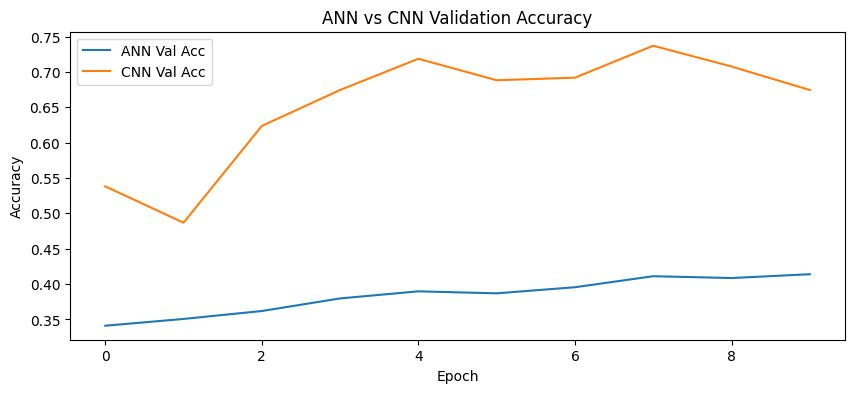

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4222
1,CNN,0.6624


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

## 🛠️ Implementing Beginner Tasks
We will now upgrade the architectures and training loops based on the tasks suggested above.

In [12]:

ann_upgraded = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(1024, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_upgraded.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Training Upgraded ANN...")
ann_upgraded_history = ann_upgraded.fit(x_train_flat, y_train, epochs=10, validation_split=0.1, batch_size=64, verbose=0)
print("Upgraded ANN Training Complete.")

Training Upgraded ANN...
Upgraded ANN Training Complete.


In [15]:

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

enhanced_cnn = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

enhanced_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Training Enhanced CNN with Augmentation (Max 20 Epochs)...")
enhanced_history = enhanced_cnn.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Training Enhanced CNN with Augmentation (Max 20 Epochs)...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 110s 151ms/step - accuracy: 0.4082 - loss: 1.7653 - val_accuracy: 0.3626 - val_loss: 2.1547
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 107s 151ms/step - accuracy: 0.5171 - loss: 1.3619 - val_accuracy: 0.5212 - val_loss: 1.4735
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 152ms/step - accuracy: 0.5632 - loss: 1.2431 - val_accuracy: 0.5208 - val_loss: 1.4406
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 107s 152ms/step - accuracy: 0.5888 - loss: 1.1733 - val_accuracy: 0.5742 - val_loss: 1.3694
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 106s 151ms/step - accuracy: 0.6105 - loss: 1.1177 - val_accuracy: 0.6270 - val_loss: 1.1004
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 149ms/step - accuracy: 0.6255 - loss: 1.0681 - val_accuracy: 0.6406 - val_loss: 1.0989
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 105s 150ms/step - accuracy: 0.6443 - loss: 1.0246 - val_accuracy: 0.6566 - val_loss: 1.0364
Epoch 8/20
704/70

In [16]:
_, ann_up_acc = ann_upgraded.evaluate(x_test_flat, y_test, verbose=0)
_, cnn_en_acc = enhanced_cnn.evaluate(x_test_norm, y_test, verbose=0)

print(f"Upgraded ANN Accuracy: {ann_up_acc:.4f}")
print(f"Enhanced CNN Accuracy: {cnn_en_acc:.4f}")

Upgraded ANN Accuracy: 0.4718
Enhanced CNN Accuracy: 0.7171


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**